In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from sklearn.datasets import load_iris

In [28]:
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target

In [29]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
df['species']=df['target'].map({
    0:'setosa',
    1:'versicolor',
    2:'virginica'
})

In [31]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [32]:
print("\n statistic summary")
df.describe


 statistic summary


<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1

In [33]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

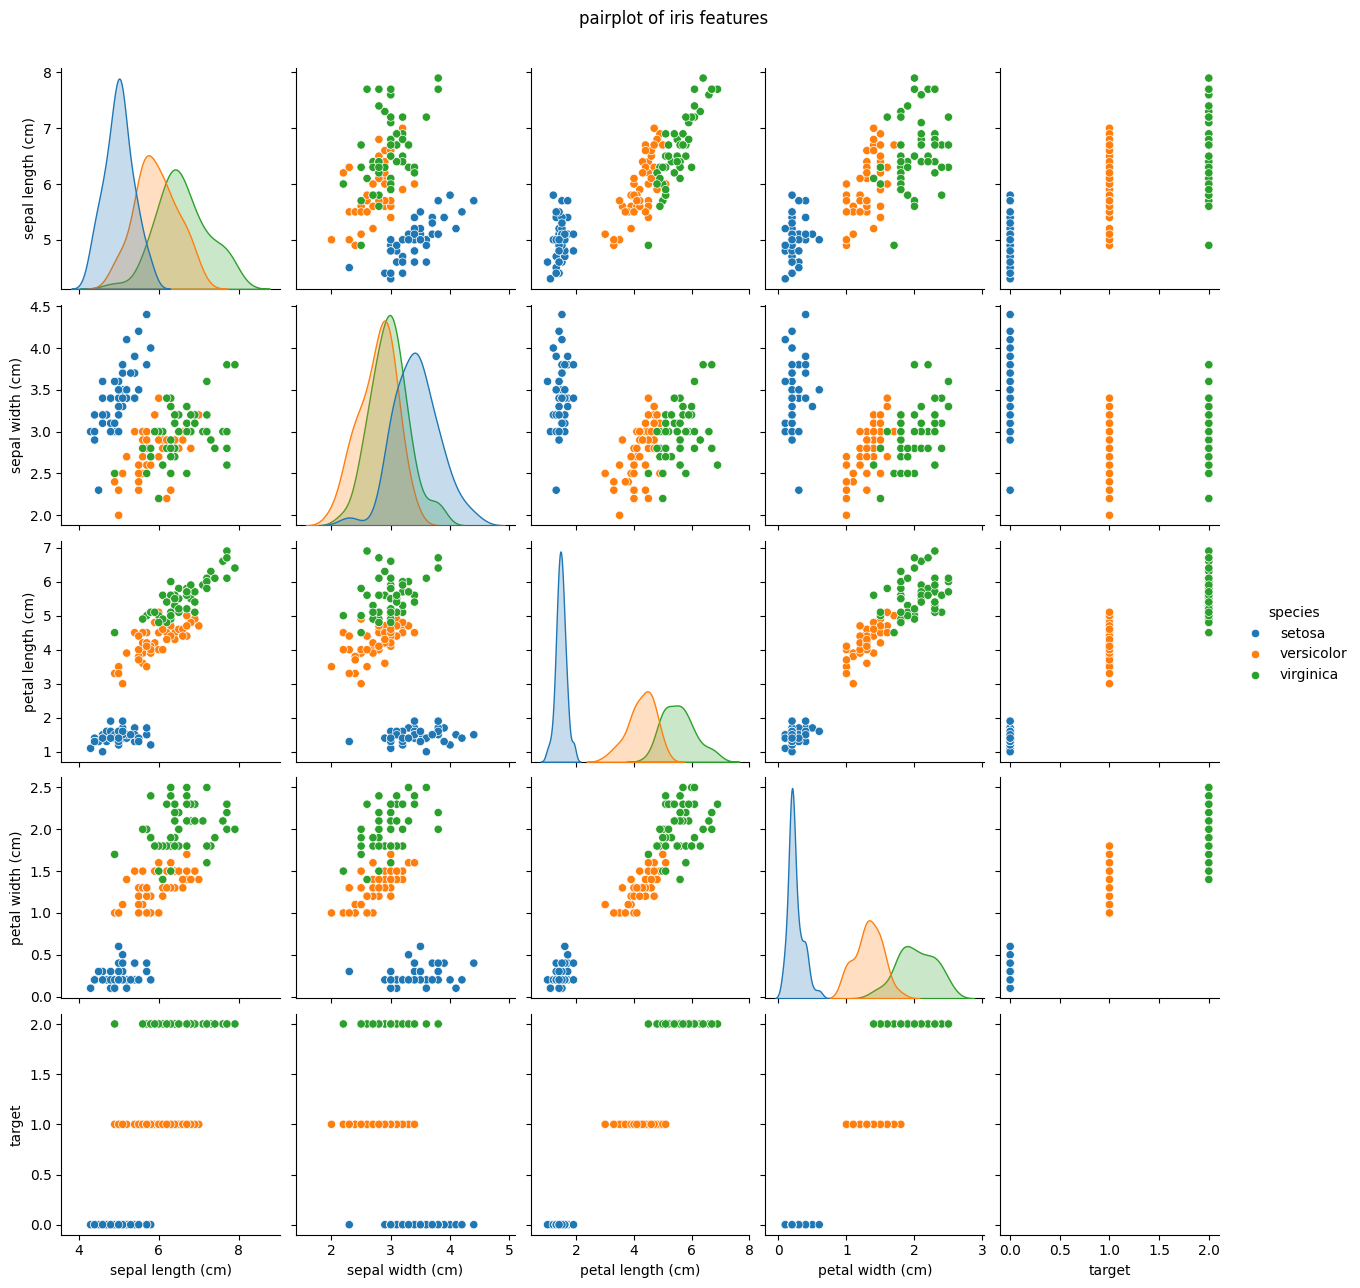

In [34]:
sns.pairplot(df,hue='species')
plt.suptitle("pairplot of iris features",y=1.03)
plt.show()

In [35]:
df.groupby('species').mean() #to find best separator

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
species,,,,,
setosa,5.006,3.428,1.462,0.246,0.0
versicolor,5.936,2.770,4.260,1.326,1.0
virginica,6.588,2.974,5.552,2.026,2.0


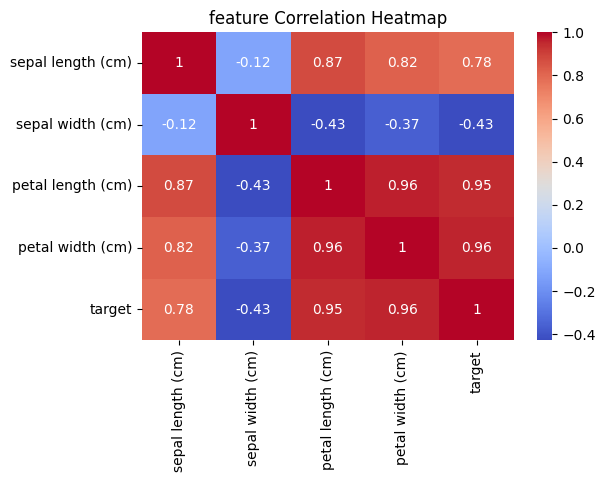

In [36]:
plt.figure(figsize=(6,4))
sns.heatmap(df.drop('species',axis=1).corr(),annot=True,cmap='coolwarm')
plt.title("feature Correlation Heatmap")
plt.show()

In [37]:
X=df.drop(['target','species'],axis=1)
y=df['target']

In [38]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [39]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [40]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [41]:
y_pred=model.predict(x_test)

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("model Accuracy",accuracy_score(y_test,y_pred))

model Accuracy 1.0


In [43]:
cm=confusion_matrix(y_test,y_pred)

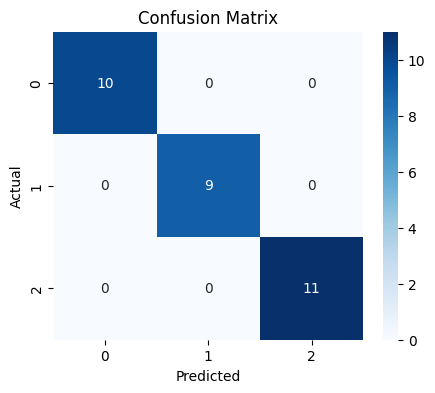

In [44]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [45]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [46]:
# Model Coefficients (Feature Importance)
coef_df = pd.DataFrame(model.coef_, columns=X.columns)
coef_df.index = ['Setosa', 'Versicolor', 'Virginica']

In [47]:
print("\nFeature Importance (Coefficients):")
print(coef_df)


Feature Importance (Coefficients):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Setosa              -1.021026          1.131551          -1.814717   
Versicolor           0.534396         -0.283571          -0.342732   
Virginica            0.486630         -0.847980           2.157449   

            petal width (cm)  
Setosa             -1.687631  
Versicolor         -0.731034  
Virginica           2.418665  


In [48]:
print("\nIntercept:")
print(model.intercept_)


Intercept:
[-0.24853241  1.97284408 -1.72431167]


In [1]:
#Final Insights
print("\n Key Insights:")
print("Petal length and petal width are the most important features.")
print("Setosa class is perfectly separable.")
print("Versicolor and Virginica show slight overlap.")
print("Logistic Regression performs very well (100% accuracy).")


 Key Insights:
Petal length and petal width are the most important features.
Setosa class is perfectly separable.
Versicolor and Virginica show slight overlap.
Logistic Regression performs very well (100% accuracy).
